In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime
import PMDevice
import keyboard
import TLX_5

In [2]:
# Power meter connection

power_meter = PMDevice.PMDevice()
power_meter.find_devices()
power_meter.connect()

Number of found devices: 1

Resource name of device 0: USB0::0x1313::0x80B4::250214211::INSTR

Device connected
Last calibration date: 14-FEB-2025 



In [3]:
# Wavelength in nm
w = 1550
power_meter.set_wavelength(w)

In [4]:
power_meter.set_autorange(True)

In [5]:
units = "dBm"

power_meter.set_unit(units)

Units set to dBm


In [6]:
power_meter.newTimeOut(20)

In [8]:
power_meter.SetAvMeasure(2)

In [14]:
p = power_meter.read_power()
print(p)

2.4662


In [15]:
measure = power_meter.measure_series(count=5, interval=1)

2025-11-24 13:34:15.197930 : -69.865 dBm
2025-11-24 13:34:16.202252 : -81.0645 dBm
2025-11-24 13:34:17.205931 : -71.2153 dBm
2025-11-24 13:34:18.210097 : -80.6314 dBm
2025-11-24 13:34:19.214135 : -66.4196 dBm



In [ ]:
while True:
    p = power_meter.read_power()
    print(f"Power={p} {units}")
    time.sleep(1.0)
    if keyboard.is_pressed("q"):
        break

Power=-60.377 dBm
Power=-59.7936 dBm
Power=-60.2401 dBm
Power=-59.946 dBm
Power=-60.0174 dBm
Power=-60.4475 dBm
Power=-60.0546 dBm
Power=-60.0885 dBm
Power=-59.9502 dBm
Power=-60.2979 dBm
Power=-60.275 dBm
Power=-60.1452 dBm
Power=-60.055 dBm
Power=-60.0332 dBm
Power=-60.8573 dBm
Power=-59.8973 dBm
Power=-60.0979 dBm
Power=-60.1861 dBm
Power=-59.9612 dBm
Power=-59.9022 dBm


In [ ]:
power_meter.disconnect()

In [ ]:
# # Laser Connection

# laser = TLX_5.TRL_5()

# port = "COM4"

# laser.connect(port)

Serial<id=0x1d24fa26e30, open=True>(port='COM4', baudrate=115200, bytesize=8, parity='N', stopbits=1, timeout=1.0, xonxoff=False, rtscts=False, dsrdtr=False)

In [12]:
measure_length = np.linspace(0, 100, 101)

size=len(measure_length)


In [15]:


power_meter.newTimeOut(20)

power_meter.SetAvMeasureTime(2)

mes_power = []

time=[]
 


In [16]:
for i in range(size):
    time.append(datetime.now())
    pwr = power_meter.read_power()
    mes_power.append(pwr)

    
    

In [27]:
mean=np.mean(mes_power)
std=np.std(mes_power)
print(f"Mean Power={mean:.2f} Standard Deviation ={std:.2f}")


Mean Power=2.48 Standard Deviation =0.01


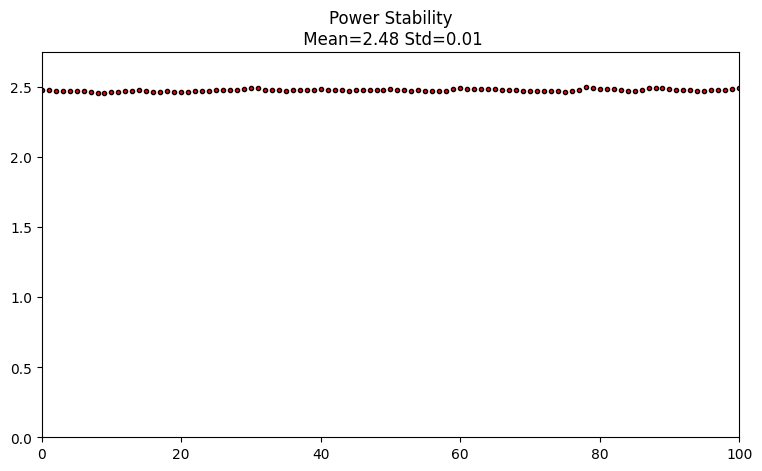

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    measure_length,mes_power,
    marker='o',         # square markers
    markersize=3,
    markerfacecolor='red',
    markeredgecolor='black',
    linestyle='None'    # disables line
)
    
ax.set_xlim(np.min(measure_length),np.max(measure_length))
ax.set_ylim(0,np.max(mes_power)+0.1*np.max(mes_power))
plt.title(f"Power Stability\n Mean={mean:.2f} Std={std:.2f}")
plt.show()

In [15]:
laser.laser_OFF()

'1'